Stroke Prediction-Analysis & Visualization

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.shape # rows and columns

(5110, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
# checking Missing Values
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
#filling missing values
df['bmi']=df['bmi'].fillna(df['bmi'].mean())

In [ ]:
#again checking missing values
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [ ]:
# checking duplicates rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#drop dupliicates values
df.drop_duplicates(inplace=True)

In [ ]:
# stroke value Counts
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
#Gender Count
df['gender'].value_counts()

,count
gender,
Female,2994
Male,2115
Other,1


In [ ]:
df['work_type'].value_counts()

,count
work_type,
Private,2925
Self-employed,819
children,687
Govt_job,657
Never_worked,22


Visualization Visual Analysis:

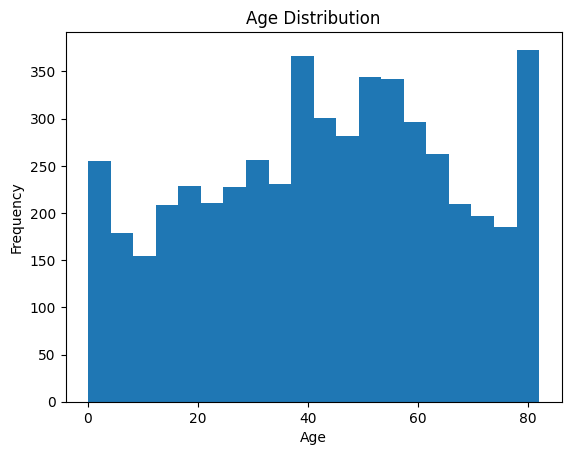

In [ ]:
plt.hist(df['age'],bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

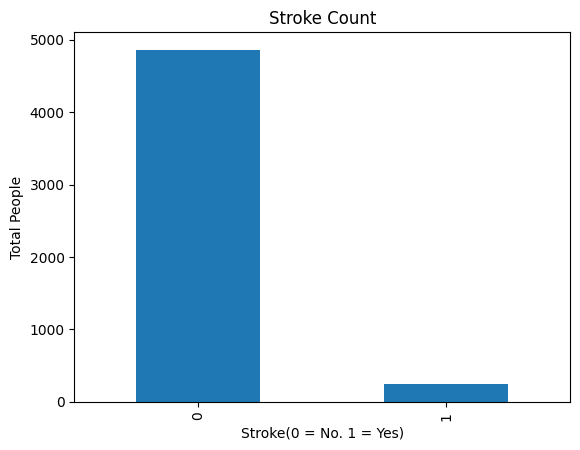

In [ ]:
df['stroke'].value_counts().plot(kind='bar')
plt.title('Stroke Count')
plt.xlabel('Stroke(0 = No. 1 = Yes)')
plt.ylabel('Total People')
plt.show()

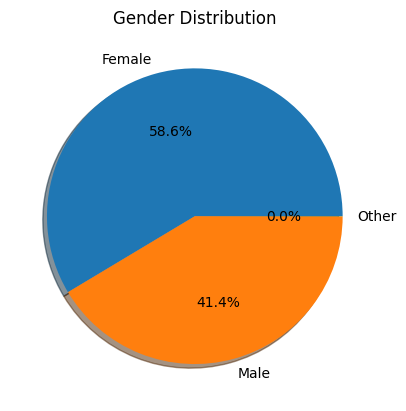

In [ ]:
df['gender'].value_counts().plot(kind='pie',autopct='%0.1f%%',shadow=True)
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

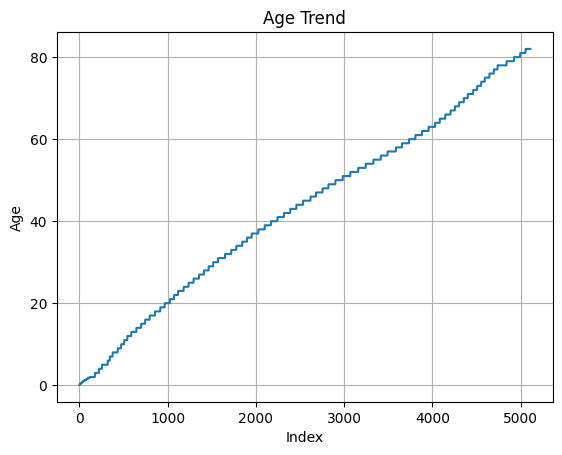

In [ ]:
sorted_age = df['age'].sort_values().reset_index(drop=True)

plt.plot(sorted_age)
plt.title('Age Trend')
plt.xlabel('Index')
plt.ylabel('Age')
plt.grid()
plt.show()

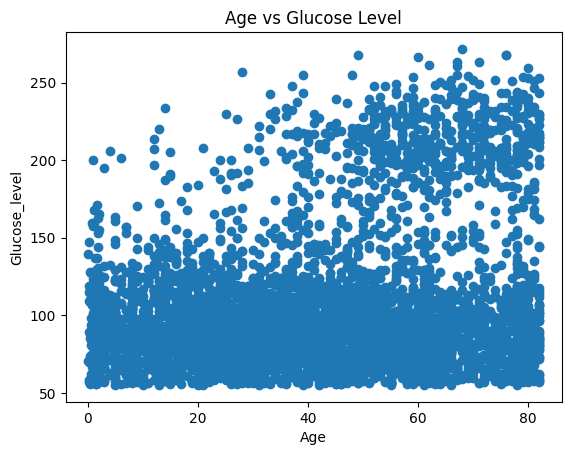

In [ ]:
plt.scatter(df['age'],df['avg_glucose_level'])
plt.title('Age vs Glucose Level')
plt.xlabel('Age')
plt.ylabel('Glucose_level')
plt.show()

In [ ]:
df.groupby('stroke')['age'].mean() #age vs stroke

,age
stroke,
0,41.971545
1,67.728193


In [ ]:
# Glucose vs stroke
df.groupby('stroke')['avg_glucose_level'].mean()

,avg_glucose_level
stroke,
0,104.795513
1,132.544739


In [ ]:
# Bmi vs Stroke
df.groupby('stroke')['bmi'].mean()

,bmi
stroke,
0,28.825388
1,30.217789


Short Analytical report:

Summary:

.  Dataset shows stroke is more common in older individuals.

. People with high average glucose levels also have a higher stroke rate.

. Smokers and formarly smoked individuals have more stroke risk compared to non-smokers.

. BMI shows a moderaate relationship with stroke accurance.

. Gender has very little impact on stroke chance in this dataset.

Overall, age and glucose level are the strongest indicaters of stroke in this
dataset.